<img src="assets/banner.png" alt="Banner" style="width:100%; border-radius:10px; margin-bottom:20px;">

# 📊 02 - Training Visualization & Data Diagrams
**Author:** Mostafa  
**License:** MIT License

In this notebook, I wanted to visually explore the dataset and present how well our model learned during the training phase. 
I've written code to load the `training_history.json` that was generated from my Kaggle training session and transform that raw data into beautiful, interactive charts. This is perfect for presentations!

In [10]:
# --- Import Required Libraries ---
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Seaborn for professional and beautiful presentation plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12}) # Increase base font size for better readability

In [11]:
# --- Load Model Training History ---
# Define the path to the training metrics extracted from the Kaggle environment
OUTPUTS_DIR = "project_outputs" 
history_path = os.path.join(OUTPUTS_DIR, "training_history.json")

# Verify the file exists before loading
if not os.path.exists(history_path):
    print("⚠️ Error: 'training_history.json' was not found. Please extract your Kaggle outputs here.")
else:
    with open(history_path, "r") as f:
        history = json.load(f)
    print("✅ Training history loaded successfully!")

✅ Training history loaded successfully!


Loading raw dataset from: ..\data\processed\cleaned.csv



C:\Users\tofa2\AppData\Local\Temp\ipykernel_42232\2565344067.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='product', order=order, palette='viridis')


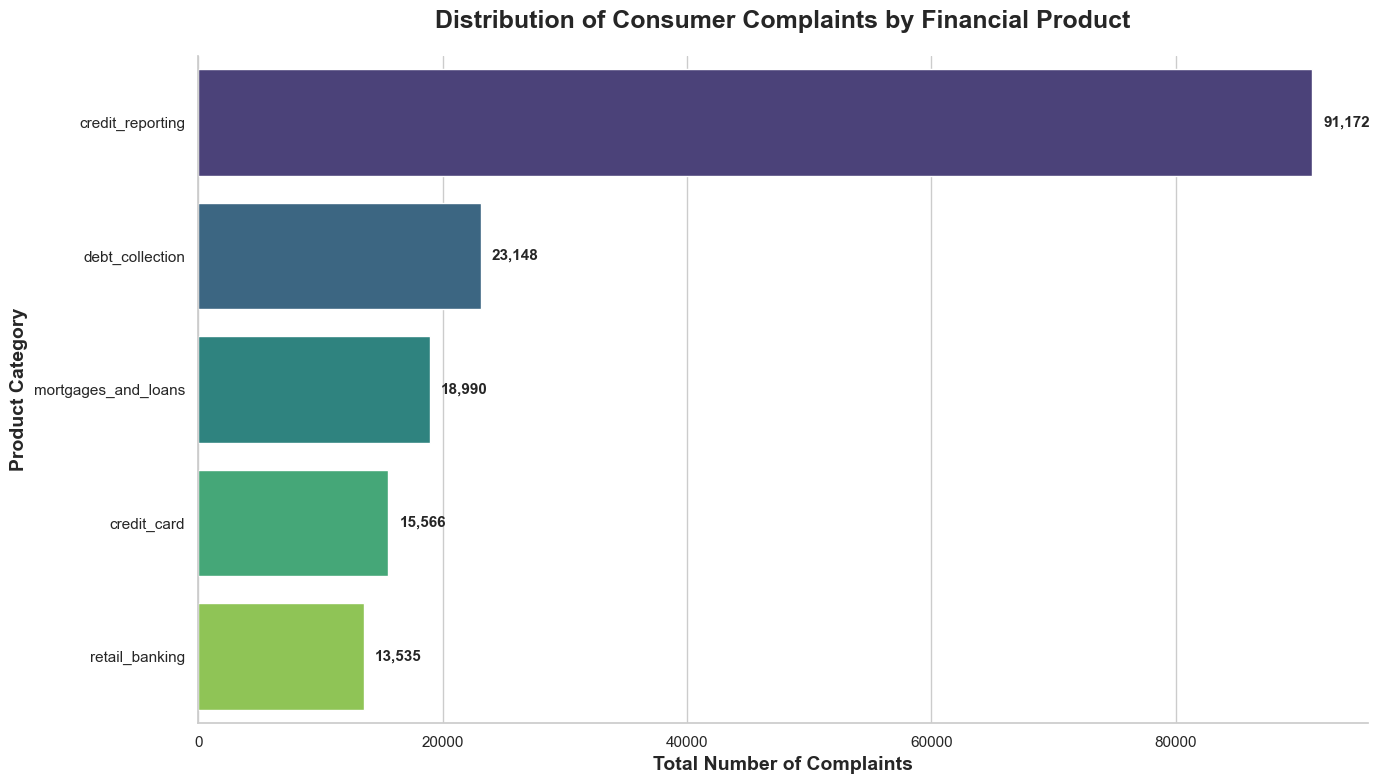

In [12]:
# --- 1. Dataset Distribution Diagram ---
# Dynamically search for the raw CSV dataset in the project directory
csv_files = glob.glob("../**/*.csv", recursive=True)

if csv_files:
    DATA_PATH = csv_files[0]
    print(f"Loading raw dataset from: {DATA_PATH}\n")
    df = pd.read_csv(DATA_PATH)
    
    # Initialize the plot figure
    plt.figure(figsize=(14, 8))
    
    # Sort categories by complaint count for a structured visual hierarchy
    order = df['product'].value_counts().index
    
    # Create a beautiful horizontal bar chart
    ax = sns.countplot(data=df, y='product', order=order, palette='viridis')
    
    # Annotate each bar with the exact number of complaints
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}', 
                    (p.get_width(), p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(8, 0), textcoords='offset points', fontsize=11, fontweight='bold')
        
    # Styling the chart for presentation
    plt.title('Distribution of Consumer Complaints by Financial Product', fontsize=18, fontweight='bold', pad=20)
    plt.xlabel('Total Number of Complaints', fontsize=14, fontweight='bold')
    plt.ylabel('Product Category', fontsize=14, fontweight='bold')
    
    # Remove top and right borders for a cleaner look
    sns.despine()
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not find the original dataset (.csv) locally to plot the distribution.")


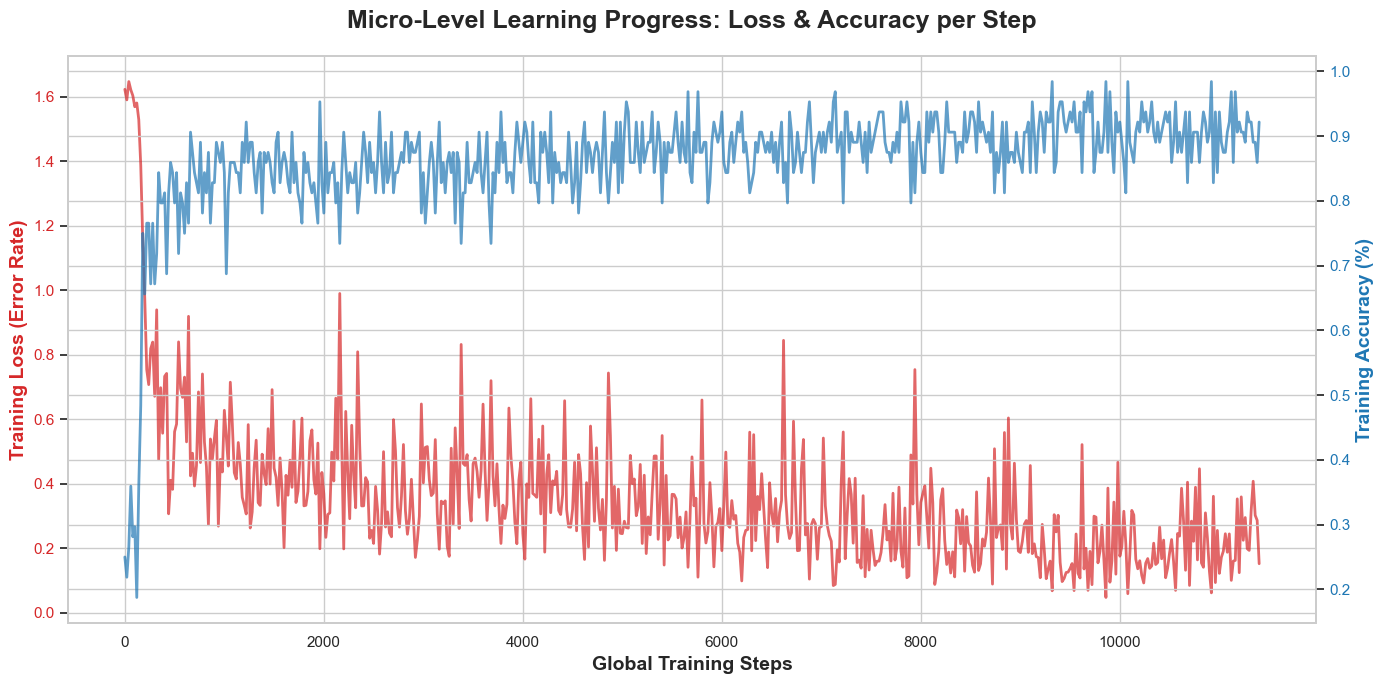

In [13]:
# --- 2. Step-by-Step Training Metrics ---
# Visualize how the model learned at every single step (batch) during training
if 'history' in locals() and len(history.get("step_metrics", [])) > 0:
    steps_df = pd.DataFrame(history["step_metrics"])
    
    fig, ax1 = plt.subplots(figsize=(14, 7))
    
    # Plot 1: Training Loss (Red Line)
    color = 'tab:red'
    ax1.set_xlabel('Global Training Steps', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Training Loss (Error Rate)', color=color, fontsize=14, fontweight='bold')
    sns.lineplot(data=steps_df, x='step', y='loss', ax=ax1, color=color, alpha=0.7, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create a secondary Y-axis for Accuracy
    ax2 = ax1.twinx()  
    
    # Plot 2: Training Accuracy (Blue Line)
    color = 'tab:blue'
    ax2.set_ylabel('Training Accuracy (%)', color=color, fontsize=14, fontweight='bold')
    sns.lineplot(data=steps_df, x='step', y='accuracy', ax=ax2, color=color, alpha=0.7, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title('Micro-Level Learning Progress: Loss & Accuracy per Step', fontsize=18, fontweight='bold', pad=20)
    fig.tight_layout()
    plt.show()

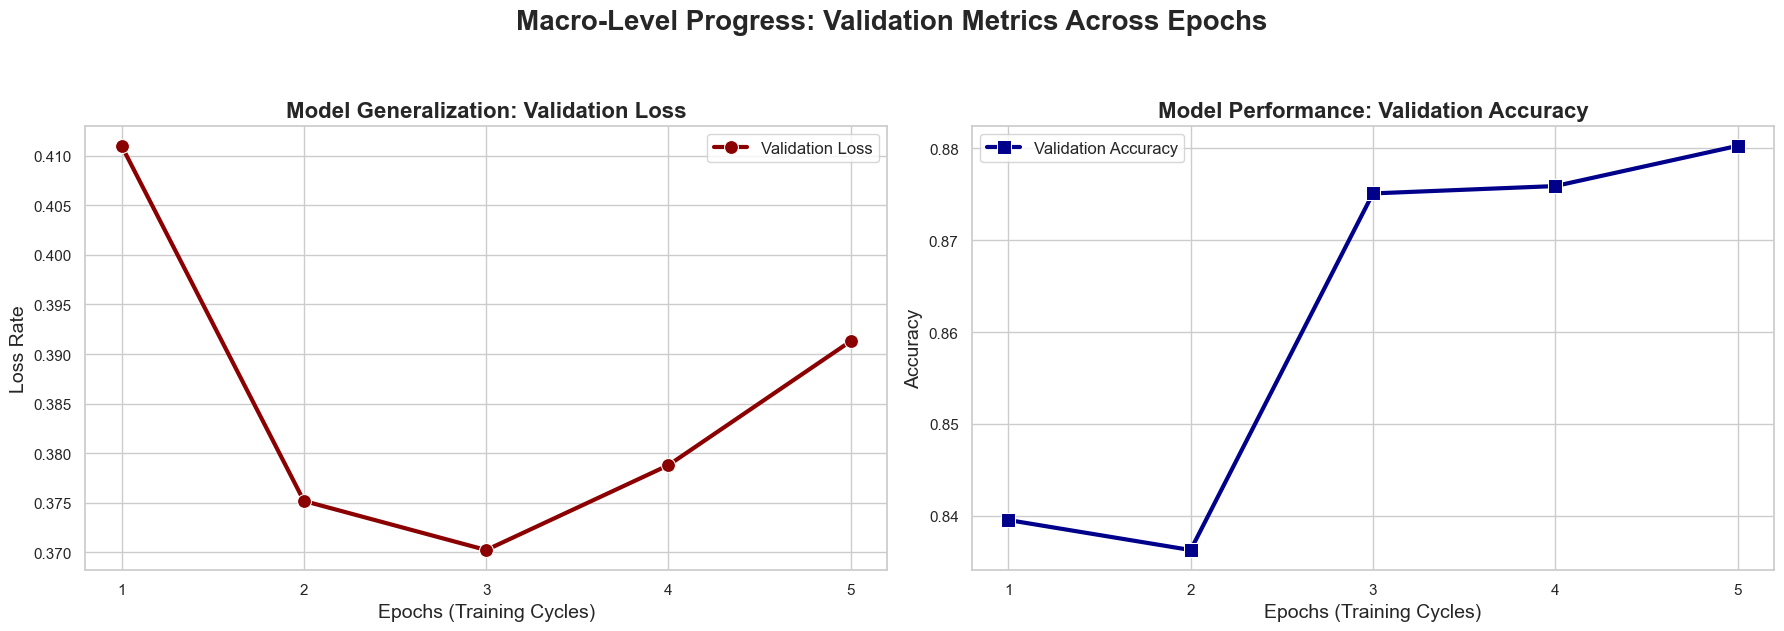

In [14]:
# --- 3. Epoch-by-Epoch Validation Metrics ---
# Compare Validation Loss and Validation Accuracy side-by-side
if 'history' in locals() and len(history.get("epoch_metrics", [])) > 0:
    epoch_df = pd.DataFrame(history["epoch_metrics"])
    
    # Create a 1x2 grid for side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Graph 1: Validation Loss (Lower is better)
    sns.lineplot(data=epoch_df, x='epoch', y='val_loss', marker='o', markersize=10, 
                 label='Validation Loss', color='darkred', linewidth=3, ax=axes[0])
    axes[0].set_title('Model Generalization: Validation Loss', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('Epochs (Training Cycles)', fontsize=14)
    axes[0].set_ylabel('Loss Rate', fontsize=14)
    axes[0].set_xticks(epoch_df['epoch'])
    axes[0].legend(fontsize=12)
    
    # Graph 2: Validation Accuracy (Higher is better)
    sns.lineplot(data=epoch_df, x='epoch', y='val_acc', marker='s', markersize=10, 
                 label='Validation Accuracy', color='darkblue', linewidth=3, ax=axes[1])
    axes[1].set_title('Model Performance: Validation Accuracy', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Epochs (Training Cycles)', fontsize=14)
    axes[1].set_ylabel('Accuracy', fontsize=14)
    axes[1].set_xticks(epoch_df['epoch'])
    axes[1].legend(fontsize=12)
    
    # Add a global title for the figure
    fig.suptitle('Macro-Level Progress: Validation Metrics Across Epochs', fontsize=20, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.show()